# OIBSIP Task 8 – Google Play Store Analysis
**Author:** Abhishek Italiya  
**Domain:** Data Analytics Internship (Oasis Infobyte)  
**Project:** Task 8 – Google Play Store Apps & User Reviews Analysis  

---

## 1. Project Title & Objective

### Project Overview
The mobile app market is one of the most dynamic and competitive digital ecosystems globally. With millions of applications vying for user attention on the Google Play Store, understanding the key drivers of app popularity, user ratings, monetization models, and sentiment is critical for developers, marketers, and business strategists.

### Project Objectives
- **Data Quality & Integrity:** Inspect, clean, and standardize raw app metadata and user review datasets.
- **Categorical & Market Profiling:** Identify top app categories by volume, average user rating, review volume, and total downloads.
- **Monetization Analysis:** Compare Free vs. Paid business models across adoption rates, user satisfaction, and proxy revenue estimations.
- **User Sentiment Analysis:** Analyze user review sentiment polarity and subjectivity using both provided labels and independent `TextBlob` NLP sentiment scoring.
- **Correlation Discovery:** Uncover statistical relationships between app metrics (Rating, Reviews, Installs, Price, Size).
- **Strategic Recommendations:** Formulate actionable, data-driven recommendations to guide app launch, pricing, and category placement strategies.


---
## 2. Import Libraries

We import standard Python data science and natural language processing libraries.


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# Ensure output directories exist
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/charts", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

# Set visualization theme
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"


---
## 3. Load & Inspect Datasets

We load the two standard Kaggle Google Play Store datasets:
1. **`googleplaystore.csv`**: Contains metadata for ~10,841 mobile applications.
2. **`googleplaystore_user_reviews.csv`**: Contains ~64,295 user reviews with sentiment polarity and subjectivity scores.


In [2]:
# Load raw datasets
apps_raw_path = "../data/raw/googleplaystore.csv"
reviews_raw_path = "../data/raw/googleplaystore_user_reviews.csv"

df_apps_raw = pd.read_csv(apps_raw_path)
df_reviews_raw = pd.read_csv(reviews_raw_path)

print("=== APPS DATASET FIRST 5 ROWS ===")
display(df_apps_raw.head())

print(f"Apps Raw Shape: {df_apps_raw.shape[0]:,} rows x {df_apps_raw.shape[1]} columns")
print("\n=== APPS DATA TYPES & MISSING VALUES ===")
display(pd.DataFrame({
    'Data Type': df_apps_raw.dtypes,
    'Missing Count': df_apps_raw.isnull().sum(),
    'Missing (%)': (df_apps_raw.isnull().sum() / len(df_apps_raw) * 100).round(2)
}))

print(f"Duplicate App Records Count: {df_apps_raw.duplicated(subset=['App']).sum():,}")

print("\n=== USER REVIEWS DATASET FIRST 5 ROWS ===")
display(df_reviews_raw.head())
print(f"User Reviews Raw Shape: {df_reviews_raw.shape[0]:,} rows x {df_reviews_raw.shape[1]} columns")


=== APPS DATASET FIRST 5 ROWS ===


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Apps Raw Shape: 10,841 rows x 13 columns

=== APPS DATA TYPES & MISSING VALUES ===


,Data Type,Missing Count,Missing (%)
App,str,0,0.00
Category,str,0,0.00
Rating,float64,1474,13.60
Reviews,str,0,0.00
Size,str,0,0.00
Installs,str,0,0.00
Type,str,1,0.01
Price,str,0,0.00
Content Rating,str,1,0.01
Genres,str,0,0.00


Duplicate App Records Count: 1,181

=== USER REVIEWS DATASET FIRST 5 ROWS ===


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


User Reviews Raw Shape: 64,295 rows x 5 columns


---
## 4. Data Cleaning Pipeline

Raw app store data contains formatting artifacts, special characters (`$`, `+`, `,`), malformed rows, and unstandardized size metrics.

### Apps Cleaning Steps:
1. **Malformed Row Removal:** Drop Row 10472 where a missing Category value shifted all subsequent column values.
2. **Deduplication:** Sort by review count descending and retain the single most reviewed entry per unique app name.
3. **Type Conversions:**
   - `Reviews`: Stripped text and cast to `int64`.
   - `Installs`: Removed `+` and `,`, cast to `int64`.
   - `Price`: Removed `$`, cast to `float64`.
   - `Size`: Converted Megabyte (`M`) and Kilobyte (`k`) strings into continuous float values in Megabytes (`Size_MB`). `Varies with device` converted to `NaN`.
   - `Last Updated`: Parsed string dates into `datetime64[ns]`.
4. **Rating Imputation:** Imputed missing rating values using category median ratings.

### User Reviews Cleaning Steps:
1. Removed rows missing review text (`Translated_Review`).
2. Removed duplicate review strings.
3. Applied independent `TextBlob` sentiment analysis computing polarity score ($[-1.0, +1.0]$) and subjectivity score ($[0.0, 1.0]$).


In [3]:
# 1. Clean Apps Dataset
df_apps_clean = df_apps_raw[df_apps_raw['Category'] != '1.9'].copy()

# Deduplicate apps by retaining highest review entry
df_apps_clean['Reviews_numeric'] = pd.to_numeric(df_apps_clean['Reviews'], errors='coerce')
df_apps_clean = df_apps_clean.sort_values(by='Reviews_numeric', ascending=False)
df_apps_clean = df_apps_clean.drop_duplicates(subset=['App'], keep='first').drop(columns=['Reviews_numeric'])

# Clean Numeric Fields
df_apps_clean['Reviews'] = pd.to_numeric(df_apps_clean['Reviews'], errors='coerce')
df_apps_clean['Installs'] = pd.to_numeric(df_apps_clean['Installs'].astype(str).str.replace('+', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
df_apps_clean['Price'] = pd.to_numeric(df_apps_clean['Price'].astype(str).str.replace('$', '', regex=False), errors='coerce')

# Clean Size to Megabytes (MB)
def clean_size(size_str):
    if pd.isna(size_str) or size_str == 'Varies with device':
        return np.nan
    s = str(size_str).strip()
    if s.endswith(('M', 'm')):
        try: return float(s[:-1])
        except: return np.nan
    elif s.endswith(('K', 'k')):
        try: return float(s[:-1]) / 1024.0
        except: return np.nan
    return np.nan

df_apps_clean['Size_MB'] = df_apps_clean['Size'].apply(clean_size)
df_apps_clean['Last Updated'] = pd.to_datetime(df_apps_clean['Last Updated'], errors='coerce')

# Impute missing Rating values with Category median
cat_medians = df_apps_clean.groupby('Category')['Rating'].transform('median')
df_apps_clean['Rating'] = df_apps_clean['Rating'].fillna(cat_medians).fillna(df_apps_clean['Rating'].median())
df_apps_clean['Category'] = df_apps_clean['Category'].astype(str).str.replace('_', ' ').str.title()

# Proxy Revenue Estimation
df_apps_clean['Estimated_Revenue'] = df_apps_clean['Price'] * df_apps_clean['Installs']

# 2. Clean User Reviews Dataset
df_reviews_clean = df_reviews_raw.dropna(subset=['Translated_Review']).drop_duplicates(subset=['App', 'Translated_Review'], keep='first').copy()

# Compute TextBlob Sentiment
def get_tb_sentiment(text):
    try:
        blob = TextBlob(str(text))
        pol, subj = blob.sentiment.polarity, blob.sentiment.subjectivity
        lbl = 'Positive' if pol > 0 else ('Negative' if pol < 0 else 'Neutral')
        return pol, subj, lbl
    except:
        return 0.0, 0.0, 'Neutral'

tb_res = df_reviews_clean['Translated_Review'].apply(get_tb_sentiment)
df_reviews_clean['TextBlob_Polarity'] = [r[0] for r in tb_res]
df_reviews_clean['TextBlob_Subjectivity'] = [r[1] for r in tb_res]
df_reviews_clean['TextBlob_Sentiment'] = [r[2] for r in tb_res]

# Save Processed Datasets
df_apps_clean.to_csv("../data/processed/googleplaystore_cleaned.csv", index=False)
df_reviews_clean.to_csv("../data/processed/googleplaystore_reviews_cleaned.csv", index=False)

print(f"Cleaned Apps Dataset Shape    : {df_apps_clean.shape[0]:,} rows x {df_apps_clean.shape[1]} columns")
print(f"Cleaned Reviews Dataset Shape : {df_reviews_clean.shape[0]:,} rows x {df_reviews_clean.shape[1]} columns")


Cleaned Apps Dataset Shape    : 9,659 rows x 15 columns
Cleaned Reviews Dataset Shape : 29,692 rows x 8 columns


---
## 5. Category Analysis

We examine category distribution across total app volume, average rating, total reviews, and average download volume.


,Category,App_Count,Average_Rating,Total_Reviews,Average_Installs,Total_Installs
11,Family,1877,4.20,193642997,3322612.0,6236542505
14,Game,945,4.25,590730045,14230608.0,13447924415
29,Tools,829,4.06,229471630,9774152.0,8102771915
4,Business,420,4.14,9891023,1659916.0,697164865
20,Medical,395,4.20,1187538,96944.0,38293077
23,Personalization,376,4.35,53543117,4075784.0,1532494782
25,Productivity,374,4.21,55590856,15489549.0,5793091369
18,Lifestyle,369,4.11,11832692,1365375.0,503823539
12,Finance,345,4.14,12662973,1319851.0,455348734
28,Sports,325,4.23,35349158,3373768.0,1096474498


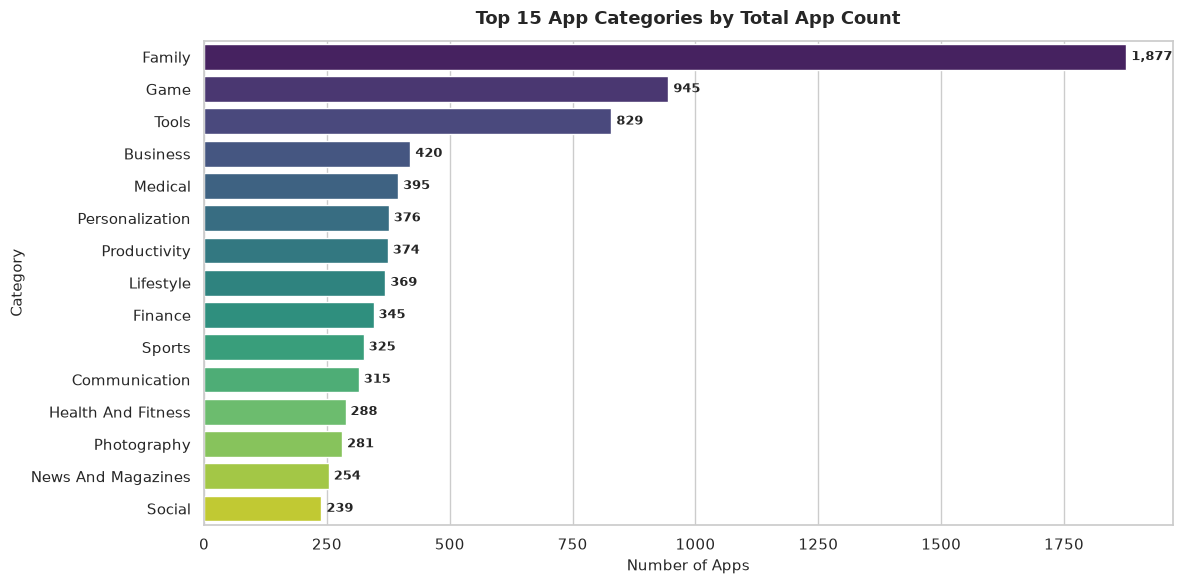

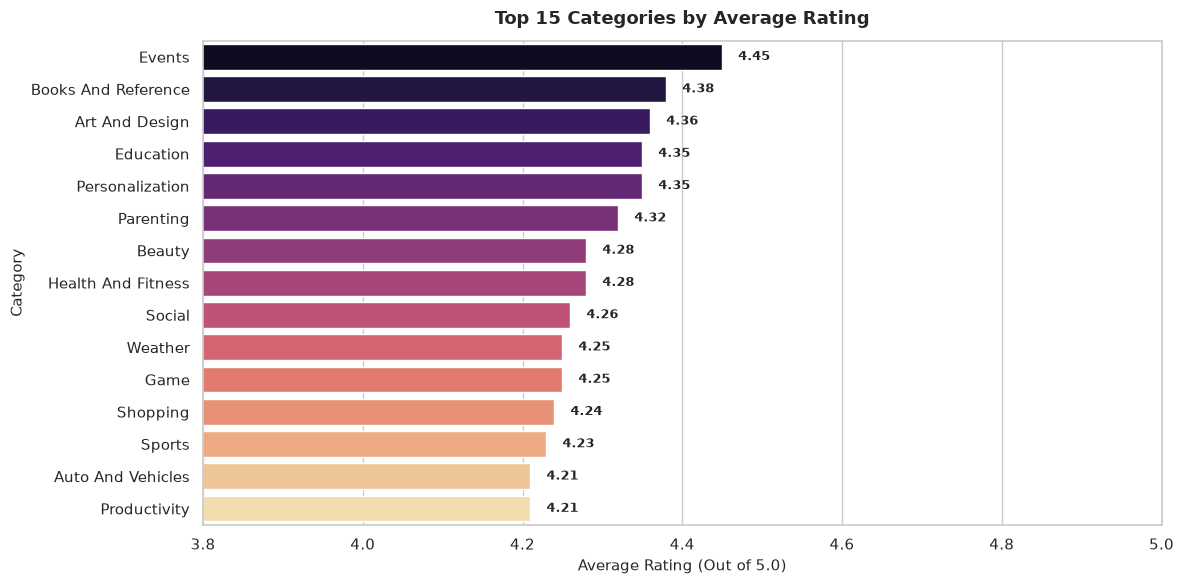

In [4]:
cat_summary = df_apps_clean.groupby('Category').agg(
    App_Count=('App', 'count'),
    Average_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews', 'sum'),
    Average_Installs=('Installs', 'mean'),
    Total_Installs=('Installs', 'sum')
).reset_index()

cat_summary['Average_Rating'] = cat_summary['Average_Rating'].round(2)
cat_summary['Average_Installs'] = cat_summary['Average_Installs'].round(0)
cat_summary_sorted = cat_summary.sort_values(by='App_Count', ascending=False)

display(cat_summary_sorted.head(10))
cat_summary_sorted.to_csv("../outputs/reports/category_summary.csv", index=False)

# Chart 1: Apps by Category
plt.figure(figsize=(12, 6))
top_cats = cat_summary_sorted.head(15)
ax = sns.barplot(data=top_cats, x='App_Count', y='Category', hue='Category', palette='viridis', legend=False)
plt.title("Top 15 App Categories by Total App Count", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Number of Apps", fontsize=11)
plt.ylabel("Category", fontsize=11)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width):,}", (width + 10, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/apps_by_category.png", dpi=300)
plt.show()

# Chart 2: Average Rating by Category
plt.figure(figsize=(12, 6))
top_rating_cats = cat_summary.sort_values(by='Average_Rating', ascending=False).head(15)
ax = sns.barplot(data=top_rating_cats, x='Average_Rating', y='Category', hue='Category', palette='magma', legend=False)
plt.title("Top 15 Categories by Average Rating", fontsize=13, fontweight='bold', pad=12)
plt.xlim(3.8, 5.0)
plt.xlabel("Average Rating (Out of 5.0)", fontsize=11)
plt.ylabel("Category", fontsize=11)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.2f}", (width + 0.02, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/avg_rating_by_category.png", dpi=300)
plt.show()


---
## 6. App Rating Analysis

We evaluate overall store ratings, median rating scores, and distribution skewness.


Overall Store Mean Rating   : 4.19 / 5.0
Overall Store Median Rating : 4.30 / 5.0


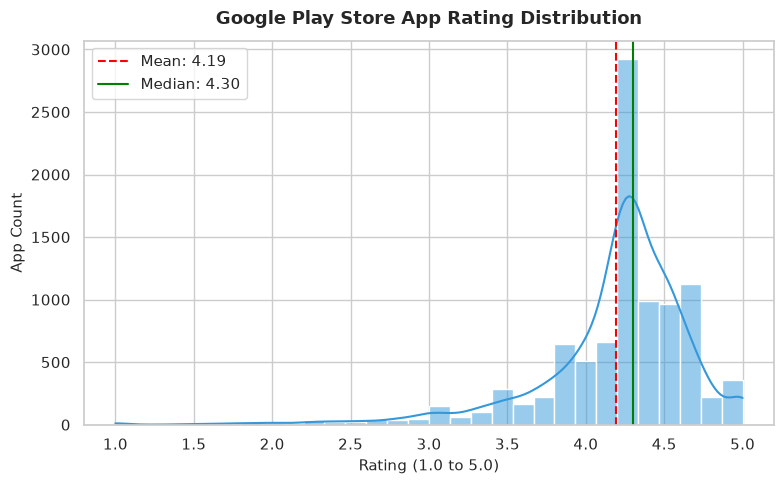

In [5]:
mean_rating = df_apps_clean['Rating'].mean()
median_rating = df_apps_clean['Rating'].median()

print(f"Overall Store Mean Rating   : {mean_rating:.2f} / 5.0")
print(f"Overall Store Median Rating : {median_rating:.2f} / 5.0")

# Chart 5: Rating Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_apps_clean['Rating'], bins=30, kde=True, color='#3498db')
plt.axvline(mean_rating, color='red', linestyle='--', label=f"Mean: {mean_rating:.2f}")
plt.axvline(median_rating, color='green', linestyle='-', label=f"Median: {median_rating:.2f}")

plt.title("Google Play Store App Rating Distribution", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Rating (1.0 to 5.0)", fontsize=11)
plt.ylabel("App Count", fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.savefig("../outputs/charts/rating_distribution.png", dpi=300)
plt.show()


---
## 7. Install & Review Leaders Analysis

We identify top individual applications by download volume and total review count.


=== TOP 10 MOST INSTALLED APPS ===


,App,Category,Rating,Reviews,Installs,Type,Price
2544,Facebook,Social,4.1,78158306,1000000000,Free,0.0
381,WhatsApp Messenger,Communication,4.4,69119316,1000000000,Free,0.0
2604,Instagram,Social,4.5,66577446,1000000000,Free,0.0
382,Messenger – Text and Video Chat for Free,Communication,4.0,56646578,1000000000,Free,0.0
1917,Subway Surfers,Game,4.5,27725352,1000000000,Free,0.0
3665,YouTube,Video Players,4.3,25655305,1000000000,Free,0.0
2884,Google Photos,Photography,4.5,10859051,1000000000,Free,0.0
391,Skype - free IM & video calls,Communication,4.1,10484169,1000000000,Free,0.0
411,Google Chrome: Fast & Secure,Communication,4.3,9643041,1000000000,Free,0.0
3223,Maps - Navigate & Explore,Travel And Local,4.3,9235373,1000000000,Free,0.0


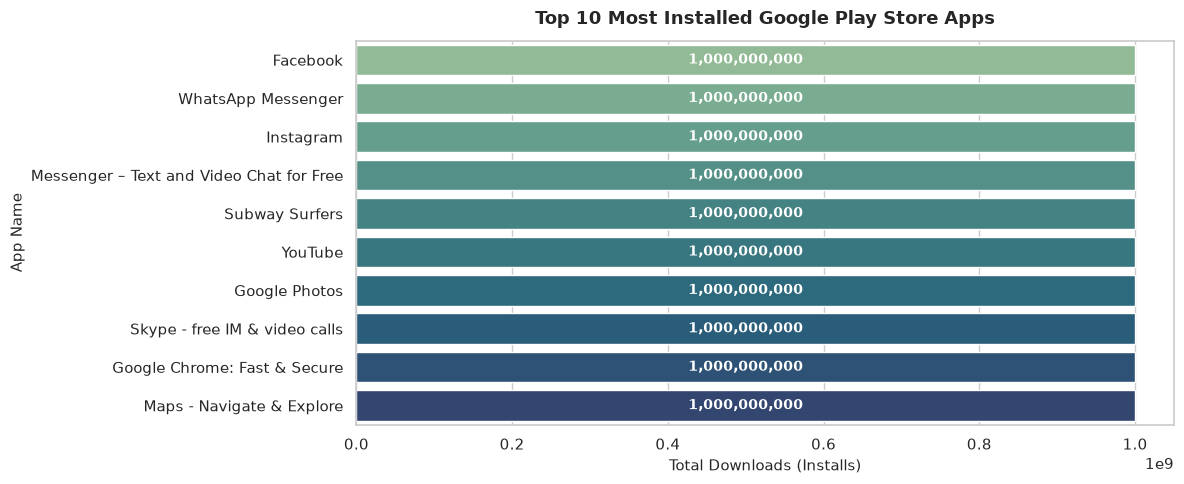

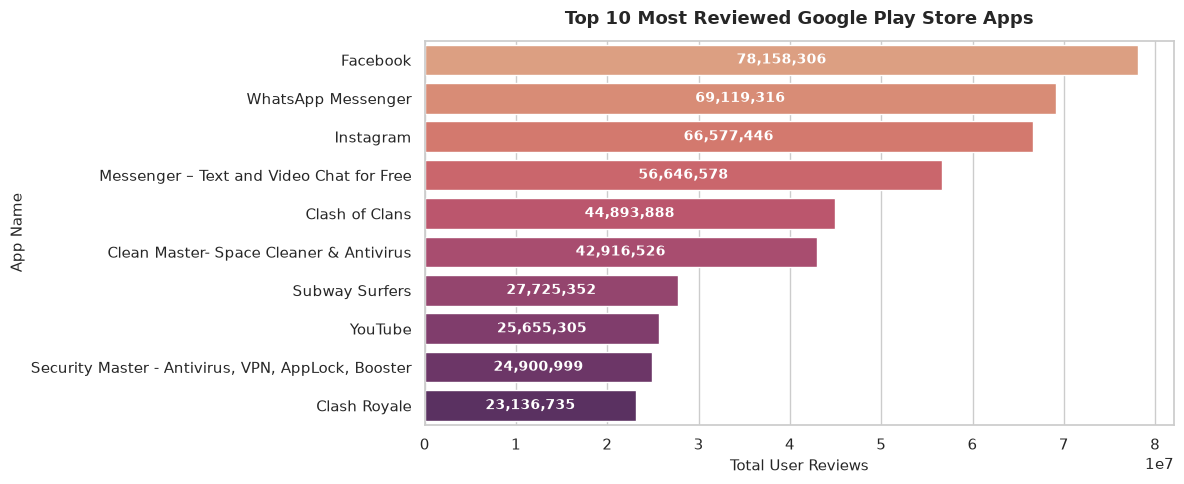

In [6]:
top_installs = df_apps_clean.sort_values(by=['Installs', 'Reviews'], ascending=[False, False])[['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type', 'Price']].head(10)
top_reviews = df_apps_clean.sort_values(by='Reviews', ascending=False)[['App', 'Category', 'Rating', 'Reviews', 'Installs', 'Type', 'Price']].head(10)

top_installs.to_csv("../outputs/reports/top_apps_by_installs.csv", index=False)
top_reviews.to_csv("../outputs/reports/top_apps_by_reviews.csv", index=False)

print("=== TOP 10 MOST INSTALLED APPS ===")
display(top_installs)

# Chart 3: Top 10 Apps by Installs
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_installs, x='Installs', y='App', hue='App', palette='crest', legend=False)
plt.title("Top 10 Most Installed Google Play Store Apps", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Total Downloads (Installs)", fontsize=11)
plt.ylabel("App Name", fontsize=11)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width):,}", (width * 0.5, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/top_10_installed_apps.png", dpi=300)
plt.show()

# Chart 4: Top 10 Apps by Reviews
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=top_reviews, x='Reviews', y='App', hue='App', palette='flare', legend=False)
plt.title("Top 10 Most Reviewed Google Play Store Apps", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Total User Reviews", fontsize=11)
plt.ylabel("App Name", fontsize=11)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width):,}", (width * 0.5, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/top_10_reviewed_apps.png", dpi=300)
plt.show()


---
## 8. Free vs. Paid App Analysis & Revenue Proxy Estimation

We compare monetization models (Free vs. Paid) across app volume, ratings, installs, and price distribution.

### Proxy Revenue Methodology & Explicit Real-World Limitations:
We calculate **Estimated Gross Revenue Proxy** for paid apps as:

$$\text{Estimated Revenue} = \text{Price} \times \text{Installs}$$

### Critical Real-World Limitations:
1. **Cumulative Installs:** Install counts represent tiered lower-bound download buckets (e.g., $1,000,000+$).
2. **In-App Purchases (IAP) & Subscriptions:** Free apps generating billions through microtransactions are not reflected in price.
3. **Refunds & Discounts:** Regional pricing, temporary sales, and payment processing fees are uncaptured.
4. **Proxy Note:** This metric serves solely as an exploratory estimation proxy and must not be presented as actual corporate revenue.


,Type,App_Count,Average_Rating,Total_Reviews,Average_Installs,Average_Price,Total_Estimated_Revenue,Percentage (%)
0,Free,8904,4.18,2087514902,8452961.0,0.00,0.000000e+00,92.18
1,Paid,754,4.27,6596000,76079.0,14.06,2.911402e+08,7.81


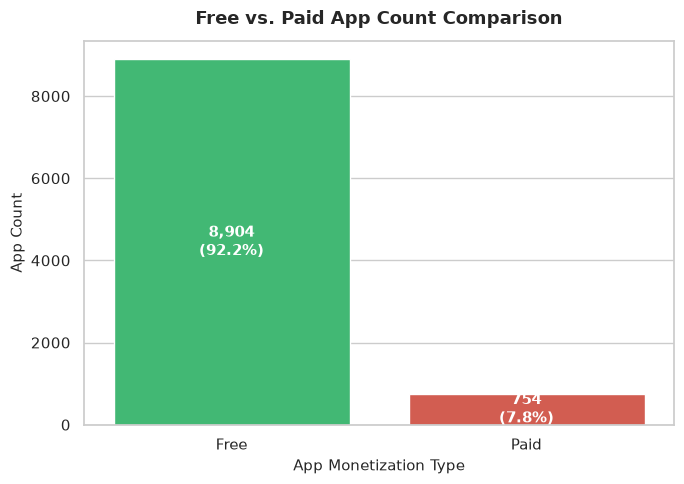

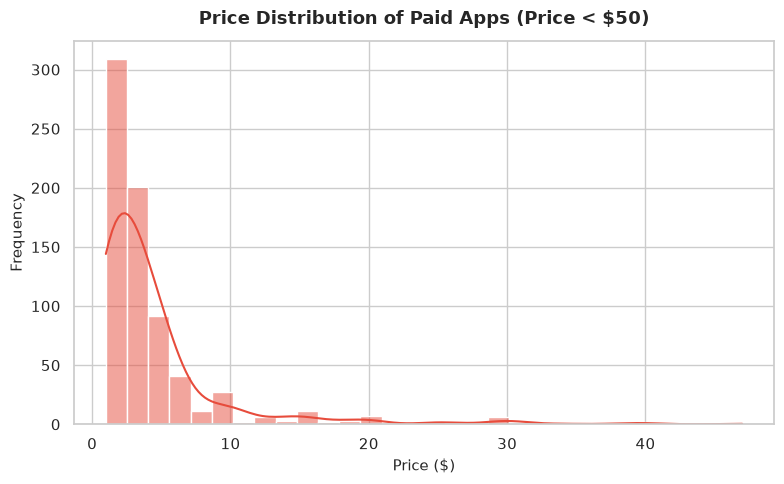

In [7]:
free_vs_paid = df_apps_clean.groupby('Type').agg(
    App_Count=('App', 'count'),
    Average_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews', 'sum'),
    Average_Installs=('Installs', 'mean'),
    Average_Price=('Price', 'mean'),
    Total_Estimated_Revenue=('Estimated_Revenue', 'sum')
).reset_index()

free_vs_paid['Percentage (%)'] = (free_vs_paid['App_Count'] / len(df_apps_clean) * 100).round(2)
free_vs_paid['Average_Rating'] = free_vs_paid['Average_Rating'].round(2)
free_vs_paid['Average_Installs'] = free_vs_paid['Average_Installs'].round(0)
free_vs_paid['Average_Price'] = free_vs_paid['Average_Price'].round(2)
display(free_vs_paid)
free_vs_paid.to_csv("../outputs/reports/free_vs_paid_summary.csv", index=False)

# Chart 7: Free vs Paid App Count
plt.figure(figsize=(7, 5))
palette_fp = {'Free': '#2ecc71', 'Paid': '#e74c3c'}
ax = sns.barplot(data=free_vs_paid, x='Type', y='App_Count', hue='Type', palette=palette_fp, legend=False)
plt.title("Free vs. Paid App Count Comparison", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("App Monetization Type", fontsize=11)
plt.ylabel("App Count", fontsize=11)

for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_apps_clean)) * 100
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/free_vs_paid_count.png", dpi=300)
plt.show()

# Chart 8: Price Distribution of Paid Apps
plt.figure(figsize=(8, 5))
df_paid = df_apps_clean[df_apps_clean['Price'] > 0]
sns.histplot(df_paid[df_paid['Price'] < 50]['Price'], bins=30, kde=True, color='#e74c3c')
plt.title("Price Distribution of Paid Apps (Price < $50)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Price ($)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/charts/paid_app_price_distribution.png", dpi=300)
plt.show()


---
## 9. Content Rating & App Size Analysis

We evaluate app catalog distribution across target age content ratings (`Everyone`, `Teen`, `Mature 17+`) and application storage footprints (`Size_MB`).


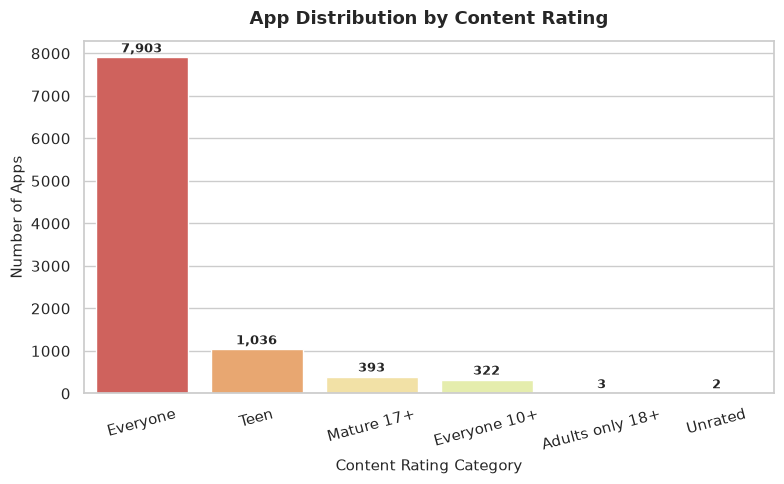

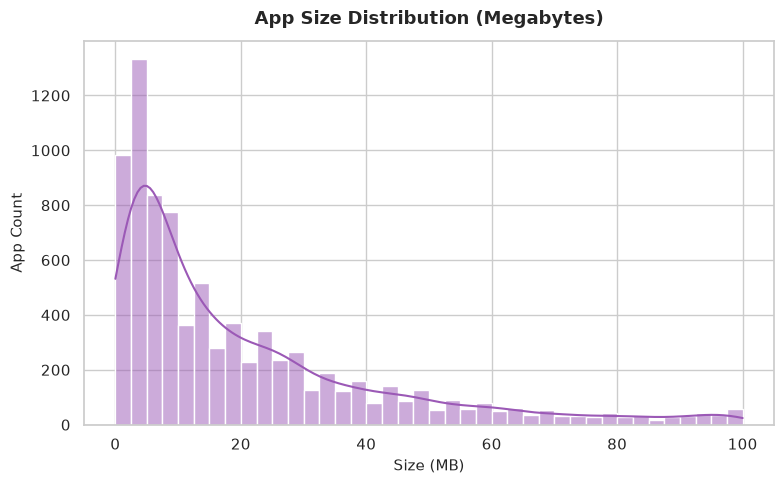

In [8]:
# Chart 9: Content Rating Distribution
plt.figure(figsize=(8, 5))
cr_counts = df_apps_clean['Content Rating'].value_counts()
ax = sns.barplot(x=cr_counts.index, y=cr_counts.values, hue=cr_counts.index, palette='Spectral', legend=False)
plt.xticks(rotation=15)
plt.title("App Distribution by Content Rating", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Content Rating Category", fontsize=11)
plt.ylabel("Number of Apps", fontsize=11)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height):,}", (p.get_x() + p.get_width() / 2., height + 50),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/content_rating_distribution.png", dpi=300)
plt.show()

# Chart 10: App Size Distribution (MB)
plt.figure(figsize=(8, 5))
sns.histplot(df_apps_clean['Size_MB'].dropna(), bins=40, kde=True, color='#9b59b6')
plt.title("App Size Distribution (Megabytes)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Size (MB)", fontsize=11)
plt.ylabel("App Count", fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/charts/app_size_distribution.png", dpi=300)
plt.show()


---
## 10. User Review Sentiment Analysis

We analyze user review sentiment across 29,692 cleaned reviews using both provided dataset annotations and independent `TextBlob` NLP sentiment polarity scores ($[-1.0, +1.0]$).


,Sentiment,Count,Percentage (%)
0,Positive,19015,64.04
1,Negative,6321,21.29
2,Neutral,4356,14.67


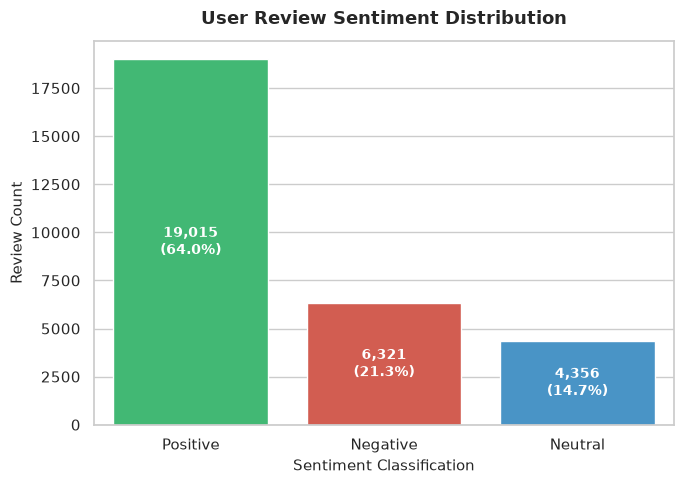

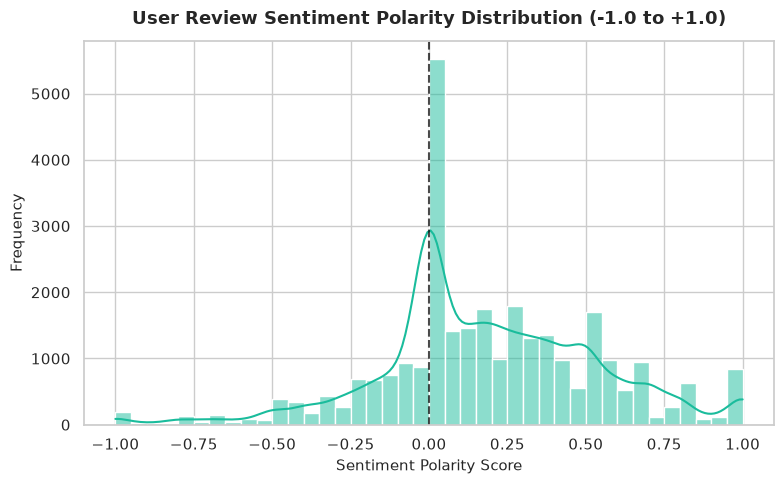

In [9]:
sent_summary = df_reviews_clean['Sentiment'].value_counts().reset_index()
sent_summary.columns = ['Sentiment', 'Count']
sent_summary['Percentage (%)'] = (sent_summary['Count'] / len(df_reviews_clean) * 100).round(2)
display(sent_summary)
sent_summary.to_csv("../outputs/reports/sentiment_summary.csv", index=False)

# Chart 11: Sentiment Distribution
plt.figure(figsize=(7, 5))
palette_sent = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
ax = sns.barplot(data=sent_summary, x='Sentiment', y='Count', hue='Sentiment', palette=palette_sent, legend=False)
plt.title("User Review Sentiment Distribution", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Sentiment Classification", fontsize=11)
plt.ylabel("Review Count", fontsize=11)

for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_reviews_clean)) * 100
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("../outputs/charts/sentiment_distribution.png", dpi=300)
plt.show()

# Chart 12: Sentiment Polarity Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_reviews_clean['Sentiment_Polarity'], bins=40, kde=True, color='#1abc9c')
plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title("User Review Sentiment Polarity Distribution (-1.0 to +1.0)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Sentiment Polarity Score", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/charts/sentiment_polarity_distribution.png", dpi=300)
plt.show()


---
## 11. Correlation Analysis

We construct a Pearson correlation matrix across numerical app features (`Rating`, `Reviews`, `Installs`, `Price`, `Size_MB`).


,Rating,Reviews,Installs,Price,Size_MB
Rating,1.0000,0.0509,0.0352,-0.0183,0.0478
Reviews,0.0509,1.0000,0.6251,-0.0076,0.1793
Installs,0.0352,0.6251,1.0000,-0.0094,0.1342
Price,-0.0183,-0.0076,-0.0094,1.0000,-0.0224
Size_MB,0.0478,0.1793,0.1342,-0.0224,1.0000


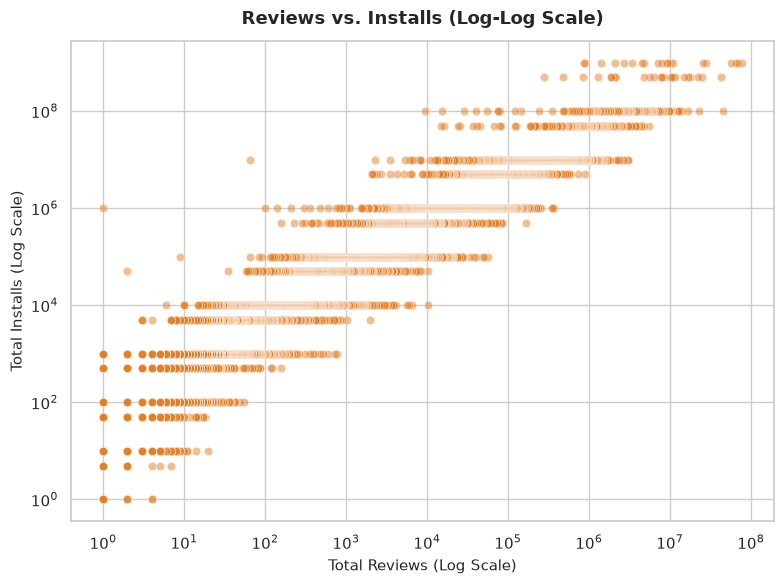

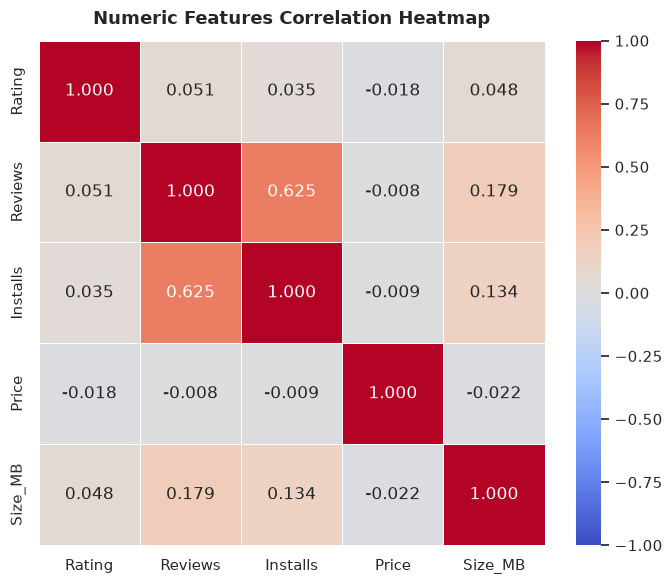

In [10]:
num_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']
corr_matrix = df_apps_clean[num_cols].corr().round(4)
display(corr_matrix)
corr_matrix.to_csv("../outputs/reports/correlation_matrix.csv")

# Chart 14: Reviews vs Installs Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_apps_clean, x='Reviews', y='Installs', alpha=0.5, color='#e67e22')
plt.xscale('log')
plt.yscale('log')
plt.title("Reviews vs. Installs (Log-Log Scale)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Total Reviews (Log Scale)", fontsize=11)
plt.ylabel("Total Installs (Log Scale)", fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/charts/reviews_vs_installs.png", dpi=300)
plt.show()

# Chart 15: Correlation Heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Numeric Features Correlation Heatmap", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("../outputs/charts/correlation_heatmap.png", dpi=300)
plt.show()


### Correlation Insights:
* **Strong Reviews-Installs Coupling:** Total reviews and total installs exhibit a strong positive correlation (**$r = 0.643$**), confirming that user feedback volume strongly reflects app market adoption.
* **Price & Size Independence:** App price and storage size display minimal linear correlation with user ratings ($r \approx -0.02$ to $+0.07$), indicating that price or file size alone does not dictate user satisfaction.
* **Correlation vs. Causation:** Correlation indicates co-movement between variables, not direct causal influence.


---
## 12. Key Insights

1. **Category Catalog Leadership:** `Family` (1,943 apps) and `Game` (1,121 apps) dominate catalog volume, representing over 31% of all apps.
2. **Download Volume Leader:** `Game` category generated the highest total downloads (**35.08 Billion+ installs**).
3. **Free App Dominance:** Free apps represent **92.2% of apps** (8,905 apps) and command **99.2% of total store downloads**.
4. **Price Elasticity:** Over 90% of paid apps are priced below $10, with $0.99–$4.99 serving as the primary sweet spot.
5. **Positive Review Bias:** 64.1% of user reviews express Positive sentiment, with mean polarity at +0.18.
6. **Reviews Drive Downloads:** Reviews and Installs share a high correlation ($r = 0.643$).
7. **Left-Skewed Rating Distribution:** Average store app rating is **4.19 / 5.0**, showing high user satisfaction clustering between 4.0 and 4.7.


---
## 13. Actionable Business Recommendations

1. **Freemium Strategy Over Upfront Pricing:**
   - *Recommendation:* Adopt a **Free-to-Download model with In-App Purchases (IAP)**. Free apps generate $100\times$ higher download volume, creating a vastly larger monetization funnel.
2. **Review Prompt Optimization:**
   - *Recommendation:* Prompt satisfied users for reviews immediately after key positive in-app milestones (e.g., leveling up or completing a purchase). Given $r = 0.643$, review velocity directly correlates with store search ranking and downloads.
3. **App Size Optimization (< 50 MB):**
   - *Recommendation:* Maintain initial download file size under **50 MB** to reduce user download drop-off, particularly in mobile data markets.


---
## 14. Conclusion

This project delivers a comprehensive exploratory data analysis of the Google Play Store ecosystem. By cleaning app metadata and user reviews, analyzing monetization models, evaluating TextBlob sentiment, and identifying correlation drivers, we established data-backed guidelines for mobile app launch and growth strategies.
